# ¿Cuál es la mejor tarifa?

Se trabaja como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Se va a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Se tienen los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. El objetivo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

## Inicialización

In [6]:
# Cargar todas las librerías
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import math
from scipy import stats as st

ModuleNotFoundError: No module named 'matplotlib'

## Cargar datos

In [ ]:
# Se cargan los archivos de datos en diferentes DataFrames
df_calls = pd.read_csv("megaline_calls.csv")
df_internet = pd.read_csv("megaline_internet.csv")
df_messages = pd.read_csv("megaline_messages.csv")
df_plans = pd.read_csv("megaline_plans.csv")
df_users = pd.read_csv("megaline_users.csv")


## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

### Primer vistazo a cada uno de los DataFrames

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas

print(df_plans.head())
df_plans.info()



   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   pla

In [4]:
# Imprime una muestra de los datos para las tarifas
print(df_users.sample(15))

     user_id  first_name  last_name  age  \
344     1344        Hugo  Daugherty   70   
262     1262   Michelina   Hamilton   34   
194     1194      Robert     Mclean   40   
462     1462      Lesley    Workman   20   
317     1317    Ruthanne      Heath   70   
30      1030       Chase       Kane   30   
63      1063    Larhonda    Hartman   60   
236     1236       Odell     Juarez   74   
279     1279        Neal       Duke   27   
360     1360      Arturo    Mullins   75   
91      1091      Taylor     Oliver   38   
422     1422  Georgianne       Huff   41   
85      1085     Ignacio    Bennett   48   
364     1364     Clarine     Bonner   75   
138     1138       Arlie    Higgins   66   

                                            city    reg_date      plan  \
344    New York-Newark-Jersey City, NY-NJ-PA MSA  2018-12-25      surf   
262          Dallas-Fort Worth-Arlington, TX MSA  2018-02-09      surf   
194       San Jose-Sunnyvale-Santa Clara, CA MSA  2018-05-31      surf   

In [5]:
#Analisis de las llamadas, mensajes y mb de internet gastados por los usurios
print(df_calls.sample(15))
print(df_messages.sample(15))
print(df_internet.sample(15))

              id  user_id   call_date  duration
83188   1301_102     1301  2018-12-11      3.92
88803   1324_862     1324  2018-11-06      1.24
90647   1328_277     1328  2018-10-31      5.35
10170    1046_36     1046  2018-08-05      0.00
30908   1115_497     1115  2018-12-26      8.35
136154  1493_316     1493  2018-10-21      3.22
16346   1064_204     1064  2018-08-17     17.85
9965    1045_130     1045  2018-10-23      2.45
90905   1328_535     1328  2018-07-02      0.74
45155   1163_214     1163  2018-09-21     12.43
43691   1159_287     1159  2018-08-25     11.85
7393    1035_231     1035  2018-12-13     11.05
83911   1305_386     1305  2018-12-16      0.00
52903    1191_51     1191  2018-12-04      5.92
116421   1408_70     1408  2018-09-06     26.63
              id  user_id message_date
19735   1126_555     1126   2018-08-02
26741    1163_21     1163   2018-11-05
15303   1101_360     1101   2018-08-19
35028   1223_125     1223   2018-09-25
36141    1240_22     1240   2018-11-0

[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Podemos ver que existen dos planes, el surf y el ultimate. Encontramos las caracteristicas de cada uno de ellos, como la cantidad de mensajes, llamadas, los mb de internet que incluyen, los precios y el costo individual de cada uno de estos servicios en caso de exceder la cantidad mensual que ofrece el paquete. En el caso de la tabla plans, los tipos de datos se ven bien, pero habra que hacer algunas modificaciones en las tablas de mensajes, llamadas y mb.

## Corregir datos

## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [6]:
# De moemnto creo que no hay factores adicionales que se pudieran añadir

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
print(df_users.head())
df_users.info()
print(df_users.isna().sum())
print(df_users.duplicated().sum())


   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    

In [8]:
# Imprime una muestra de datos para usuarios

print(df_users.sample(15))

     user_id first_name last_name  age  \
378     1378   Mckinley   Clayton   22   
148     1148      Dwana     Moore   67   
392     1392       Gale  Mcfadden   34   
67      1067       Robt     Allen   37   
333     1333       Macy     David   57   
351     1351       Kyle    Grimes   47   
119     1119   Anderson    Palmer   60   
264     1264     Jessie      Hill   69   
250     1250      Milan   Sellers   57   
149     1149     Jamaal   Camacho   54   
162     1162       Mark    Farley   20   
267     1267        Gia    Parker   53   
321     1321     Karlyn   Jimenez   19   
320     1320       Bert     Wells   23   
72      1072    Seymour    Spence   66   

                                         city    reg_date      plan  \
378            Denver-Aurora-Lakewood, CO MSA  2018-12-17      surf   
148                          Columbia, SC MSA  2018-11-04      surf   
392           Seattle-Tacoma-Bellevue, WA MSA  2018-05-24      surf   
67              Grand Rapids-Kentwood, MI M

In [9]:
#Obtener plan por usuario, de esta manera tenemos un filtrado unicamente del p´lan que tiene contratado cada usuario
usuario_plan = df_users[["user_id", "plan"]]
usuario_plan.columns = ["user_id", "plan_name"]
usuario_plan

,user_id,plan_name
0,1000,ultimate
1,1001,surf
2,1002,surf
3,1003,surf
4,1004,surf
...,...,...
495,1495,surf
496,1496,surf
497,1497,ultimate
498,1498,surf


In [10]:
#COSTO POR PLAN AL EDTALLE. Aqui obtenemos las caracteristicas, servicios y costos de cada uno de los planes para cada usuario.
plan_usuario_costos = usuario_plan.merge(df_plans, on="plan_name")
plan_usuario_costos

,user_id,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,1000,ultimate,1000,30720,3000,70,7,0.01,0.01
1,1006,ultimate,1000,30720,3000,70,7,0.01,0.01
2,1008,ultimate,1000,30720,3000,70,7,0.01,0.01
3,1011,ultimate,1000,30720,3000,70,7,0.01,0.01
4,1013,ultimate,1000,30720,3000,70,7,0.01,0.01
...,...,...,...,...,...,...,...,...,...
495,1494,surf,50,15360,500,20,10,0.03,0.03
496,1495,surf,50,15360,500,20,10,0.03,0.03
497,1496,surf,50,15360,500,20,10,0.03,0.03
498,1498,surf,50,15360,500,20,10,0.03,0.03


In [11]:
#Aqui tenemos una simplificacion que incluye user_id, plan, y el costo de cada uno
plan_usuario_costo_mensual = plan_usuario_costos[["user_id", "plan_name", "usd_monthly_pay"]]
plan_usuario_costo_mensual


,user_id,plan_name,usd_monthly_pay
0,1000,ultimate,70
1,1006,ultimate,70
2,1008,ultimate,70
3,1011,ultimate,70
4,1013,ultimate,70
...,...,...,...
495,1494,surf,20
496,1495,surf,20
497,1496,surf,20
498,1498,surf,20


Los datos se ven bien en la tabla users, podemos cambiar el tipo de dato de la fecha de registro a datetime

[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]


### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [12]:
#Se cambia el tipo de dato de la columna reg_date a tipo datetime
df_users["reg_date"] = pd.to_datetime(df_users["reg_date"])
df_users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [13]:
# Se procede a hacer conteo de cuantos usuarios tienen plan surf y cuantos ultimate
conteo_planes = df_users.groupby("plan").count()
conteo_planes

,user_id,first_name,last_name,age,city,reg_date,churn_date
plan,,,,,,,
surf,339,339,339,339,339,339,23
ultimate,161,161,161,161,161,161,11


In [14]:
conteo_planes["user_id"]

plan
surf        339
ultimate    161
Name: user_id, dtype: int64

In [15]:
# Conteo de cuantos clientes permanecen activos hasta el momento
clientes_activos = conteo_planes["user_id"].sum() - conteo_planes["churn_date"].sum()
clientes_activos

466

In [16]:

#Proporcion del plan surf 
porcentaje_surf =  100*(339/466)
porcentaje_surf


72.74678111587983

In [17]:
#Proporcion del plan ultimate
porcentaje_ultimate =  100*(161/466)
porcentaje_ultimate


34.54935622317596

Se ceunta con 466 clientes activos, de los cuales, 339 (72.74%) tienen el plan surf y 161 (34.54%) el plan ultimate

## Llamadas

In [18]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
print(df_calls.head())
df_calls.info()
print(df_calls.isna().sum())
print(df_calls.duplicated().sum())
print(df_calls["id"].duplicated().sum())

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB
id           0
user_id      0
call_date    0
duration     0
dtype: int64
0
0


In [19]:
df_calls["user_id"].nunique()
#TENEMOS UN LISTADO DE UN TOTAL DE 500 CLIENTES, Y VEMOS QUE SOLAMENTE 481 TIENEN REGISTRO DE LLAMADAS.
#LO QUE NOS PUEDE INDICAR QUE 19 USUARIOS NO REALIZARON LLAMADAS DURANTE EL PERIODO DE SU PLAN

481

In [20]:
# Imprime una muestra de datos para las llamadas
print(df_calls.sample(15))

              id  user_id   call_date  duration
112344   1396_55     1396  2018-11-24      0.00
38765    1145_12     1145  2018-12-22      6.94
93520   1334_888     1334  2018-11-10      0.00
41822   1153_661     1153  2018-12-29      5.91
116875  1408_524     1408  2018-02-09      2.34
86178   1317_297     1317  2018-12-21      0.00
85329   1313_309     1313  2018-12-12      6.99
75966   1268_470     1268  2018-04-19      0.00
137166   1498_91     1498  2018-08-24      1.02
79195    1284_48     1284  2018-10-08      0.72
50487    1182_55     1182  2018-06-16     18.55
109161  1385_231     1385  2018-05-26     15.45
59648    1215_33     1215  2018-09-20      7.98
16736   1065_104     1065  2018-11-16      9.73
136466  1494_308     1494  2018-11-17      2.96


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Se puede observar el historial de cada uno de los usuarios, vemos el id de la llamada que realizada asociada a cada id de usuario, la fecha en la que se realizó dicha llamada y la duracion de la misma, en este caso, es conveniente transformar la fecha a tipo de dato datetime, asi como redondear los segundos de la duracion de la llamada al numero superior mas cercano, para manejar numeros enteros en el consumo de minutos y calcular el precio correspondiente a cada plan. Podemos observar que posiblemente hay usurios que no suelen realizar llamadas durante la duracion de su plan, pues solo contamos con 481 registros de los 500.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [21]:
#Se transforma la fecha a tipo de dato datertime
df_calls["call_date"] = pd.to_datetime(df_calls["call_date"])
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


In [22]:
#Redondear los segundos del tiempo de duracion al entero mayor mas proximo
df_calls["duration"] = np.ceil(df_calls["duration"])
df_calls["duration"]


0          9.0
1         14.0
2         15.0
3          6.0
4          5.0
          ... 
137730     9.0
137731    11.0
137732     9.0
137733     1.0
137734    14.0
Name: duration, Length: 137735, dtype: float64

### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [23]:
#Veamos la informacion general de la columa "duration"
df_calls["duration"].describe()

count    137735.000000
mean          7.146673
std           5.953919
min           0.000000
25%           2.000000
50%           6.000000
75%          11.000000
max          38.000000
Name: duration, dtype: float64

Se puede observar que de un total de 137735 llamadas la duracion media de la llamada es de 6.7 minutos, mientras que la duracion maxima registrada es de 38 minutos. Mostrar estos datos de manera grafica podria ser util.

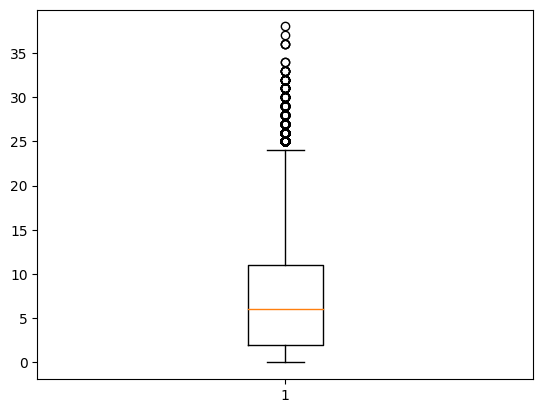

In [24]:
llamadas_duracion_plot = plt.boxplot(df_calls["duration"])

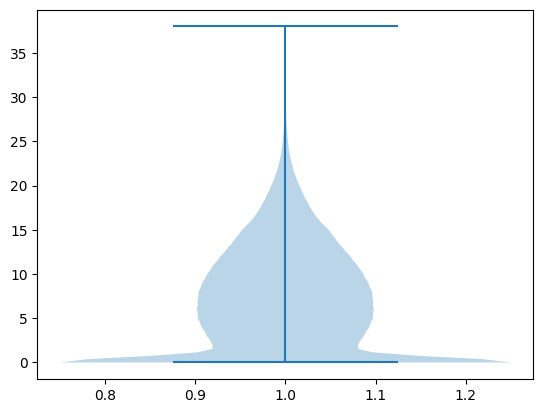

In [25]:
llamadas_duracion_violin = plt.violinplot(df_calls["duration"])

In [26]:
#Aqui podemos ver que la mayoia de las llamadas tienen una duracion de entre 5 y 7 minutos

In [27]:
#Cantidad de llamadas por cliente

llamadas_por_usuario = df_calls.groupby("user_id")["id"].count()
print("Cantidad maxima de llamadas hechas por un usuario:",llamadas_por_usuario.max())
print("Cantidad minima de llamadas hechas por un usuario:",llamadas_por_usuario.min())
llamadas_por_usuario

Cantidad maxima de llamadas hechas por un usuario: 1300
Cantidad minima de llamadas hechas por un usuario: 2


user_id
1000     16
1001    261
1002    113
1003    149
1004    370
       ... 
1495    253
1496    195
1497     54
1498    451
1499    204
Name: id, Length: 481, dtype: int64

In [28]:
#Vamos a extrar el ultimo 25% de los datos, esto resulta util pues representa la parte de los clientes que mas minutos gastan en sus llamadas.
top_clientes_llamadas = df_calls.query("duration >= 11")
top_clientes_llamadas

,id,user_id,call_date,duration
1,1000_145,1000,2018-12-27,14.0
2,1000_247,1000,2018-12-27,15.0
7,1000_521,1000,2018-12-28,15.0
11,1000_705,1000,2018-12-31,13.0
16,1001_0,1001,2018-09-06,11.0
...,...,...,...,...
137717,1499_186,1499,2018-10-08,17.0
137718,1499_187,1499,2018-12-20,11.0
137719,1499_188,1499,2018-09-29,24.0
137731,1499_200,1499,2018-10-20,11.0


## Mensajes

In [29]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
print(df_messages.head())
df_messages.info()
print(df_messages.isna().sum())
print(df_messages.duplicated().sum())
print(df_messages["id"].duplicated().sum())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB
id              0
user_id         0
message_date    0
dtype: int64
0
0


In [30]:
df_messages["user_id"].nunique()
#Aqui podemos observar que probablemente 98 usuarios no hicieron uso de mensajes durante su plan

402

In [31]:
# Imprime una muestra de datos para los mensajes
df_messages.sample(15)


,id,user_id,message_date
18124,1119_847,1119,2018-11-07
60987,1384_22,1384,2018-07-09
59245,1374_419,1374,2018-05-13
29282,1179_78,1179,2018-10-26
52111,1336_49,1336,2018-09-17
74730,1483_64,1483,2018-05-26
15549,1101_606,1101,2018-11-09
58487,1371_155,1371,2018-12-29
44779,1301_42,1301,2018-12-03
58763,1373_181,1373,2018-12-14


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Podemos ver el id de cada uno de los mensajes enviados, el id de usuario que envio cada mensaje y la fecha en que se enviaron. Puede ser conveniente transformar la columna de "message_date" a formato de fecha dt. Tambien es importante destacar que solo contamos con registros para 402 usuarios de los 500, por lo que puede ser que los 98 usuarios faltantes no hayan enviado mensajes.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [32]:
df_messages["message_date"] = pd.to_datetime(df_messages["message_date"])
df_messages.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [33]:
#Podemos hacer el conteo de mensajes por usuario
mensajes_por_usuario = df_messages.groupby("user_id")["id"].count()
print("Cantidad maxima de mensajes por usuario:", mensajes_por_usuario.max())
print("Cantidad maxima de mensajes por usuario:", mensajes_por_usuario.min())
mensajes_por_usuario

Cantidad maxima de mensajes por usuario: 1288
Cantidad maxima de mensajes por usuario: 1


user_id
1000     11
1001    207
1002     88
1003     50
1004    177
       ... 
1491    409
1492    108
1494    174
1496     65
1497     50
Name: id, Length: 402, dtype: int64

## Internet

In [34]:
# Imprime la información general/resumida sobre el DataFrame de internet
print(df_internet.head())
df_internet.info()
print(df_internet.isna().sum())
print(df_internet.duplicated().sum())
print(df_internet["id"].duplicated().sum())

         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB
id              0
user_id         0
session_date    0
mb_used         0
dtype: int64
0
0


In [35]:
df_internet["user_id"].nunique()
#Aqui podemos ver que existe la posibilidad de que 11 de los usuarios no hayan hecho uso de internet durante su plan.

489

In [36]:
# Imprime una muestra de datos para el tráfico de internet
df_internet.sample(15)


,id,user_id,session_date,mb_used
91423,1421_44,1421,2018-10-30,1142.96
61342,1278_228,1278,2018-11-23,98.36
99540,1469_33,1469,2018-12-31,907.09
32521,1147_124,1147,2018-05-17,847.67
98681,1466_162,1466,2018-09-19,0.00
99854,1472_310,1472,2018-05-10,442.01
46113,1204_46,1204,2018-12-17,593.14
41741,1185_778,1185,2018-05-05,185.41
44018,1196_14,1196,2018-11-05,312.29
83694,1390_249,1390,2018-07-11,339.87


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

Podemos ver los registros de cada usuario, cuando iniciaron una sesion de internet y cuantos mb utilizaron. Podemos redondear los decimales de la columna "mb_used" hacia el valor mas alto, contar los mb gastados por usuario y transformar la columna "session_date" a formato fecha. De igual manera, solo tenemos registro para 489 usuarios, por lo que no contamos con datos de navegacion para 11 usuarios.

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [37]:
df_internet["session_date"] = pd.to_datetime(df_internet["session_date"])
df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [38]:
#Redondear los datos hacia arriba con el valor mas proximo
df_internet["mb_used"] = np.ceil(df_internet["mb_used"])
df_internet["mb_used"]


0          90.0
1           0.0
2         661.0
3         271.0
4         881.0
          ...  
104820    219.0
104821    305.0
104822    293.0
104823      0.0
104824    759.0
Name: mb_used, Length: 104825, dtype: float64

In [39]:
#Conteo de mb gastados por usuario

mb_gastados_por_usuario = df_internet.groupby("user_id")["mb_used"].sum()
print("Cantidad maxima de mb gastados por usuario:", mb_gastados_por_usuario.max())
print("Cantidad minima de mb gastados por usuario:", mb_gastados_por_usuario.min())
mb_gastados_por_usuario

Cantidad maxima de mb gastados por usuario: 390518.0
Cantidad minima de mb gastados por usuario: 93.0


user_id
1000      1903.0
1001     80540.0
1002     40339.0
1003     27069.0
1004    156548.0
          ...   
1495     99010.0
1496     64357.0
1497     11120.0
1498    227798.0
1499     71444.0
Name: mb_used, Length: 489, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Los datos fueron revisados y modificados apropiadamente, ahora se puede empezar a trabajar con ellos comodamente
</div>


## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [40]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras

print(df_plans.head())
df_plans.info()


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   pla

## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [41]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
#Primero establecemes el formato de la fecha a AÑO-MES
df_calls["call_date"] = df_calls["call_date"].dt.to_period("M")
df_calls



,id,user_id,call_date,duration
0,1000_93,1000,2018-12,9.0
1,1000_145,1000,2018-12,14.0
2,1000_247,1000,2018-12,15.0
3,1000_309,1000,2018-12,6.0
4,1000_380,1000,2018-12,5.0
...,...,...,...,...
137730,1499_199,1499,2018-11,9.0
137731,1499_200,1499,2018-10,11.0
137732,1499_201,1499,2018-09,9.0
137733,1499_202,1499,2018-10,1.0


In [42]:
#CONTEO DE USUARIOS 
df_calls["user_id"].nunique()


481

In [43]:
#Agrupamos por user_id y mes para contar las llamadas por usuario
llamadas_usuario_mensual = df_calls.groupby(["user_id", "call_date"]).count().reset_index()
llamadas_usuario_mensual

,user_id,call_date,id,duration
0,1000,2018-12,16,16
1,1001,2018-08,27,27
2,1001,2018-09,49,49
3,1001,2018-10,65,65
4,1001,2018-11,64,64
...,...,...,...,...
2253,1498,2018-12,39,39
2254,1499,2018-09,41,41
2255,1499,2018-10,53,53
2256,1499,2018-11,45,45


In [44]:
llamadas_usuario_mensual["user_id"].nunique()

481

In [45]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutos_usuario_mensual = llamadas_usuario_mensual.groupby(["user_id", "call_date"])["duration"].sum().reset_index()
minutos_usuario_mensual.columns = ["user_id", "date", "min_qty"]
minutos_usuario_mensual

,user_id,date,min_qty
0,1000,2018-12,16
1,1001,2018-08,27
2,1001,2018-09,49
3,1001,2018-10,65
4,1001,2018-11,64
...,...,...,...
2253,1498,2018-12,39
2254,1499,2018-09,41
2255,1499,2018-10,53
2256,1499,2018-11,45


In [46]:
#CONTEO DE USUARIOS 
minutos_usuario_mensual["user_id"].nunique()



481

In [47]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
#Primero establecemes el formato de la fecha a AÑO-MES.
df_messages["message_date"] = df_messages["message_date"].dt.to_period("M")
df_messages

,id,user_id,message_date
0,1000_125,1000,2018-12
1,1000_160,1000,2018-12
2,1000_223,1000,2018-12
3,1000_251,1000,2018-12
4,1000_255,1000,2018-12
...,...,...,...
76046,1497_526,1497,2018-12
76047,1497_536,1497,2018-12
76048,1497_547,1497,2018-12
76049,1497_558,1497,2018-12


In [48]:
#CONTEO DE MENSAJES POR USUARIO

mensajes_usuario_mensual = df_messages.groupby(["user_id", "message_date"])["id"].count().reset_index()
mensajes_usuario_mensual.columns = ["user_id", "date", "message_qty"]
mensajes_usuario_mensual

,user_id,date,message_qty
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36
...,...,...,...
1801,1496,2018-09,21
1802,1496,2018-10,18
1803,1496,2018-11,13
1804,1496,2018-12,11


In [49]:

#CONTEO DE USUARIOS 
mensajes_usuario_mensual["user_id"].nunique()


402

In [50]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
#Primero establecemes el formato de la fecha a AÑO-MES.

df_internet["session_date"] = df_internet["session_date"].dt.to_period("M")
df_internet


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12,90.0
1,1000_204,1000,2018-12,0.0
2,1000_379,1000,2018-12,661.0
3,1000_413,1000,2018-12,271.0
4,1000_442,1000,2018-12,881.0
...,...,...,...,...
104820,1499_215,1499,2018-10,219.0
104821,1499_216,1499,2018-12,305.0
104822,1499_217,1499,2018-09,293.0
104823,1499_218,1499,2018-12,0.0


In [51]:
#CANTIDAD DE MB USADOS POR USUARIO
mb_usuario_mensual = df_internet.groupby(["user_id", "session_date"])["mb_used"].sum().reset_index()
mb_usuario_mensual.columns = ["user_id", "date", "mb_used"]
mb_usuario_mensual

,user_id,date,mb_used
0,1000,2018-12,1903.0
1,1001,2018-08,6929.0
2,1001,2018-09,13333.0
3,1001,2018-10,22356.0
4,1001,2018-11,18524.0
...,...,...,...
2272,1498,2018-12,23160.0
2273,1499,2018-09,13004.0
2274,1499,2018-10,19515.0
2275,1499,2018-11,16834.0


In [52]:

#CONTEO DE USUARIOS 
mb_usuario_mensual["user_id"].nunique()



489

[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [53]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
gasto_llamadas_mensajes_mb = minutos_usuario_mensual.merge(mensajes_usuario_mensual, on=["user_id", "date"], how="outer").merge(mb_usuario_mensual, on=["user_id", "date"], how="outer")
gasto_llamadas_mensajes_mb

,user_id,date,min_qty,message_qty,mb_used
0,1000,2018-12,16.0,11.0,1903.0
1,1001,2018-08,27.0,30.0,6929.0
2,1001,2018-09,49.0,44.0,13333.0
3,1001,2018-10,65.0,53.0,22356.0
4,1001,2018-11,64.0,36.0,18524.0
...,...,...,...,...,...
2288,1349,2018-12,NaN,61.0,13052.0
2289,1361,2018-05,NaN,2.0,1523.0
2290,1482,2018-10,NaN,2.0,NaN
2291,1108,2018-12,NaN,NaN,235.0


In [54]:
gasto_llamadas_mensajes_mb["user_id"].nunique()

490

Podemos observar que tenemos valores ausentes (NaN) en los apartados de ["min_qty", "message_qty", "mb_used"] ya que los usuarios relacionados a esos rows, no tienen por lo menos un registro en alguna de las columnas antes mencionadas, por lo que se procederá a rellenar dichos valores con 0.

In [55]:
#Se procede a rellenar los datos de NaN de "min_qty", "message_qty", "mb_used" con el valor de 0
gasto_llamadas_mensajes_mb["min_qty"].fillna(0, inplace=True)
gasto_llamadas_mensajes_mb["message_qty"].fillna(0, inplace=True)
gasto_llamadas_mensajes_mb["mb_used"].fillna(0, inplace=True)
gasto_llamadas_mensajes_mb

,user_id,date,min_qty,message_qty,mb_used
0,1000,2018-12,16.0,11.0,1903.0
1,1001,2018-08,27.0,30.0,6929.0
2,1001,2018-09,49.0,44.0,13333.0
3,1001,2018-10,65.0,53.0,22356.0
4,1001,2018-11,64.0,36.0,18524.0
...,...,...,...,...,...
2288,1349,2018-12,0.0,61.0,13052.0
2289,1361,2018-05,0.0,2.0,1523.0
2290,1482,2018-10,0.0,2.0,0.0
2291,1108,2018-12,0.0,0.0,235.0


In [56]:
gasto_llamadas_mensajes_mb.isna().sum()

user_id        0
date           0
min_qty        0
message_qty    0
mb_used        0
dtype: int64

In [57]:
#CONTEO DE USUARIOS 
gasto_llamadas_mensajes_mb["user_id"].nunique()




490

In [58]:
# Añade la información de la tarifa y los costos
gasto_completo_usuario_mensual = gasto_llamadas_mensajes_mb.merge(plan_usuario_costos, on="user_id")
gasto_completo_usuario_mensual

,user_id,date,min_qty,message_qty,mb_used,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,1000,2018-12,16.0,11.0,1903.0,ultimate,1000,30720,3000,70,7,0.01,0.01
1,1001,2018-08,27.0,30.0,6929.0,surf,50,15360,500,20,10,0.03,0.03
2,1001,2018-09,49.0,44.0,13333.0,surf,50,15360,500,20,10,0.03,0.03
3,1001,2018-10,65.0,53.0,22356.0,surf,50,15360,500,20,10,0.03,0.03
4,1001,2018-11,64.0,36.0,18524.0,surf,50,15360,500,20,10,0.03,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1204,2018-12,0.0,78.0,36768.0,ultimate,1000,30720,3000,70,7,0.01,0.01
2289,1349,2018-10,0.0,76.0,13105.0,surf,50,15360,500,20,10,0.03,0.03
2290,1349,2018-11,0.0,72.0,17145.0,surf,50,15360,500,20,10,0.03,0.03
2291,1349,2018-12,0.0,61.0,13052.0,surf,50,15360,500,20,10,0.03,0.03


In [59]:
#Conteo de Usuarios
gasto_completo_usuario_mensual["user_id"].nunique()

490

De los 500 usuarios que tenemos, se obtiene una tabla sin valores ausentes para un total de 490 usuarios
Esta perdida representa el 2% de perdida para este caso, se procede a realizar el analisis con la data recabada.




[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [60]:
# Calcula el ingreso mensual para cada usuario
#CALCULAR COSTO EXCEDENTE POR LLAMADAS, MENSAJES Y MB GASTADOS
def costo_total(fila):
    pago_total = fila["usd_monthly_pay"]
    if fila["min_qty"] > fila["minutes_included"]:
        pago_total += (fila["min_qty"] - fila["minutes_included"]) * fila["usd_per_minute"]

    if fila["message_qty"] > fila["messages_included"]:
        pago_total += (fila["message_qty"] - fila["messages_included"]) * fila["usd_per_message"]

    if fila["mb_used"] > fila["mb_per_month_included"]:
        pago_total += ((fila["mb_used"] - fila["mb_per_month_included"])/1024) * fila["usd_per_gb"]
    return pago_total


In [61]:
gasto_completo_usuario_mensual["costo_total"] = gasto_completo_usuario_mensual.apply(costo_total, axis=1)
gasto_completo_usuario_mensual["costo_total"] = np.ceil(gasto_completo_usuario_mensual["costo_total"])
gasto_completo_usuario_mensual

,user_id,date,min_qty,message_qty,mb_used,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,costo_total
0,1000,2018-12,16.0,11.0,1903.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
1,1001,2018-08,27.0,30.0,6929.0,surf,50,15360,500,20,10,0.03,0.03,20.0
2,1001,2018-09,49.0,44.0,13333.0,surf,50,15360,500,20,10,0.03,0.03,20.0
3,1001,2018-10,65.0,53.0,22356.0,surf,50,15360,500,20,10,0.03,0.03,89.0
4,1001,2018-11,64.0,36.0,18524.0,surf,50,15360,500,20,10,0.03,0.03,51.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1204,2018-12,0.0,78.0,36768.0,ultimate,1000,30720,3000,70,7,0.01,0.01,112.0
2289,1349,2018-10,0.0,76.0,13105.0,surf,50,15360,500,20,10,0.03,0.03,21.0
2290,1349,2018-11,0.0,72.0,17145.0,surf,50,15360,500,20,10,0.03,0.03,39.0
2291,1349,2018-12,0.0,61.0,13052.0,surf,50,15360,500,20,10,0.03,0.03,21.0


In [62]:
gasto_completo_usuario_mensual["user_id"].nunique()

490

In [63]:
gasto_completo_usuario_mensual.isna().sum()

user_id                  0
date                     0
min_qty                  0
message_qty              0
mb_used                  0
plan_name                0
messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
costo_total              0
dtype: int64

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Buena manera de agregar los datos por usuario, ahora tenemos columnas extras que nos ayudarán con el analisis posterior
</div>


## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

In [64]:
#Trabajaremos tambien con dos df distintoos, uno para el plan ultimate, y otro para el plan surf
analisis_plan_ultimate = gasto_completo_usuario_mensual.query("plan_name == 'ultimate'")
analisis_plan_surf = gasto_completo_usuario_mensual.query("plan_name == 'surf'")


In [65]:
analisis_plan_surf

,user_id,date,min_qty,message_qty,mb_used,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,costo_total
1,1001,2018-08,27.0,30.0,6929.0,surf,50,15360,500,20,10,0.03,0.03,20.0
2,1001,2018-09,49.0,44.0,13333.0,surf,50,15360,500,20,10,0.03,0.03,20.0
3,1001,2018-10,65.0,53.0,22356.0,surf,50,15360,500,20,10,0.03,0.03,89.0
4,1001,2018-11,64.0,36.0,18524.0,surf,50,15360,500,20,10,0.03,0.03,51.0
5,1001,2018-12,56.0,44.0,19398.0,surf,50,15360,500,20,10,0.03,0.03,60.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2285,1194,2018-11,0.0,62.0,42904.0,surf,50,15360,500,20,10,0.03,0.03,290.0
2286,1194,2018-12,0.0,56.0,31119.0,surf,50,15360,500,20,10,0.03,0.03,175.0
2289,1349,2018-10,0.0,76.0,13105.0,surf,50,15360,500,20,10,0.03,0.03,21.0
2290,1349,2018-11,0.0,72.0,17145.0,surf,50,15360,500,20,10,0.03,0.03,39.0


<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Siempre que se muestren los datos para su revisión se debe limitar la salida con `head` o `sample`
</div>


In [66]:
analisis_plan_surf["plan_name"].unique()

array(['surf'], dtype=object)

In [67]:
analisis_plan_ultimate

,user_id,date,min_qty,message_qty,mb_used,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,costo_total
0,1000,2018-12,16.0,11.0,1903.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
19,1006,2018-11,2.0,15.0,2072.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
20,1006,2018-12,9.0,139.0,32144.0,ultimate,1000,30720,3000,70,7,0.01,0.01,80.0
26,1008,2018-10,71.0,21.0,17131.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
27,1008,2018-11,63.0,37.0,23706.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2231,1493,2018-12,65.0,0.0,15307.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
2247,1497,2018-12,54.0,50.0,11120.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
2287,1204,2018-11,0.0,42.0,21366.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
2288,1204,2018-12,0.0,78.0,36768.0,ultimate,1000,30720,3000,70,7,0.01,0.01,112.0


In [68]:
analisis_plan_ultimate["plan_name"].unique()

array(['ultimate'], dtype=object)

In [69]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
#ANALISIS DE LLAMADAS EN EL PLAN SURF
analisis_plan_surf["min_qty"].describe()

count    1573.000000
mean       59.811825
std        32.017989
min         0.000000
25%        39.000000
50%        60.000000
75%        79.000000
max       205.000000
Name: min_qty, dtype: float64

In [70]:
#Obtenemos  la cantidad promedio de minutos gastados por los usuarios para cada uno de los meses en el plan surf.
promedio_duracion_llamadas_mes_surf = analisis_plan_surf.groupby("date")["min_qty"].mean().reset_index()
promedio_duracion_llamadas_mes_surf




,date,min_qty
0,2018-01,30.000000
1,2018-02,40.666667
2,2018-03,46.434783
3,2018-04,48.880000
4,2018-05,55.701299
5,2018-06,59.474227
6,2018-07,63.157025
7,2018-08,57.561728
8,2018-09,58.108247
9,2018-10,60.350211


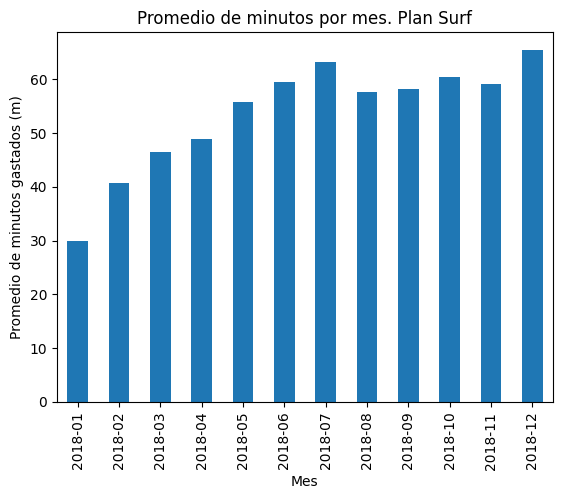

In [71]:
#Graficamos los promedios del resultado obtenido anteriormente (Promedio mensual de minutos usados) para el plan surf
promedio_duracion_llamadas_mes_surf.plot(title = "Promedio de minutos por mes. Plan Surf",
                                        kind="bar", 
                                        x="date",
                                        y="min_qty",
                                        xlabel="Mes",
                                        ylabel="Promedio de minutos gastados (m)",
                                        legend=None)
plt.show()



In [72]:
#ANALSIS DE LLAMADAS EN EL PLAN ULTIMATE


In [73]:
#Promedio del costo pagado por los usuarios del plan ultimate
analisis_plan_ultimate["costo_total"].mean()

72.15972222222223

In [74]:
#Obtenemos el promedio mensual de minutos usados por los usuarios del plan ultimate
promedio_duracion_llamadas_mes_ultimate = analisis_plan_ultimate.groupby("date")["min_qty"].mean().reset_index()
promedio_duracion_llamadas_mes_ultimate

,date,min_qty
0,2018-01,28.000000
1,2018-02,58.285714
2,2018-03,46.000000
3,2018-04,47.523810
4,2018-05,57.586207
5,2018-06,52.170213
6,2018-07,58.694915
7,2018-08,60.070423
8,2018-09,61.046512
9,2018-10,63.783019


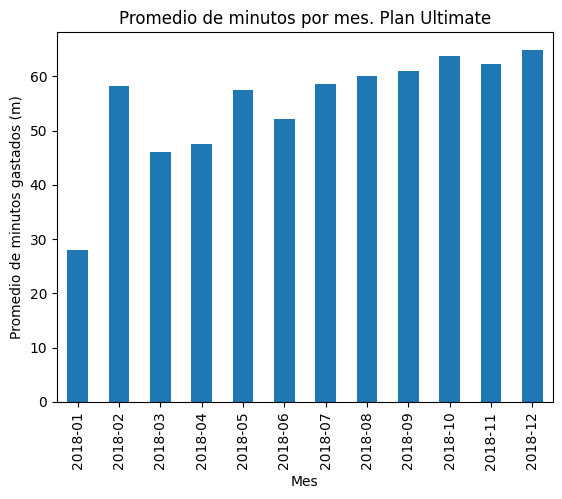

In [75]:
#Graficamos el promedio para cada mes de minutos usados en el plan ultimate
promedio_duracion_llamadas_mes_ultimate.plot(title = "Promedio de minutos por mes. Plan Ultimate",
                                        kind="bar", 
                                        x="date",
                                        y="min_qty",
                                        xlabel="Mes",
                                        ylabel="Promedio de minutos gastados (m)",
                                        legend=None)
plt.show()



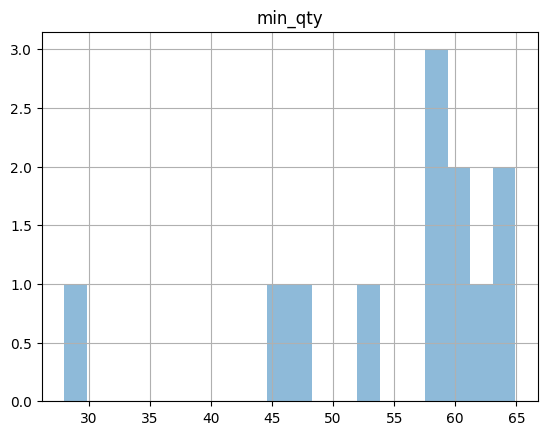

In [76]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
#Plan Ultimate
promedio_duracion_llamadas_mes_ultimate.hist(bins=20,alpha=0.5)
plt.show()

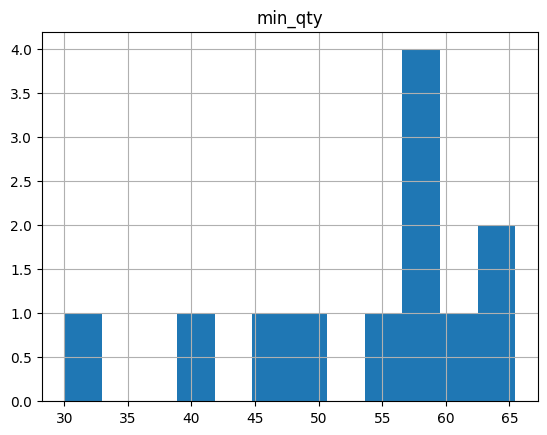

In [77]:
#Plan Surf
promedio_duracion_llamadas_mes_surf.hist(bins=12, alpha=1)
plt.show()


[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [78]:
# Calcula la media y la varianza de la duración mensual de llamadas.
#Varianza de la duracion de minutos del plan Ultimate
promedio_duracion_llamadas_mes_ultimate = analisis_plan_surf["min_qty"].var()
promedio_duracion_llamadas_mes_ultimate


1025.1515903712295

In [79]:
#Varianza de la duracion de minutos del plan Surf
dio_duracion_llamadas_mes_surf = analisis_plan_ultimate["min_qty"].var()
dio_duracion_llamadas_mes_surf


1105.0966600989025

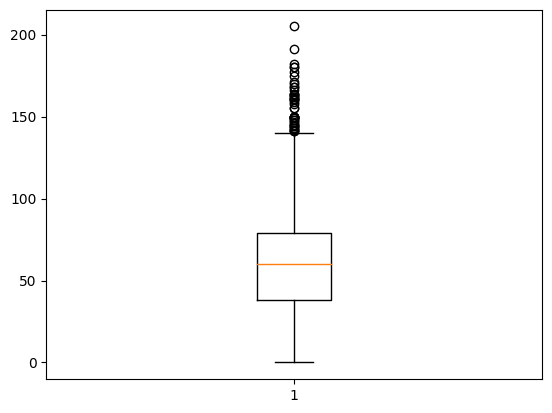

In [80]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas
#Aqui se hace un grafico de caja para las llamadas considerando ambos planes
gasto_completo_usuario_mensual_boxplot= plt.boxplot(gasto_completo_usuario_mensual["min_qty"])
plt.show()


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

El comportamiento es diferente, en el caso del plan surf, la mayoria de los ingresos provienen de lo que paga la gente por exceder los servicios que incluye el plan, mientras que en el plan ultimate, los usuarios no suelen soprepasar la cantidad de servicios que incluye su plan, por lo que no genera mucho retroactivo adicional al costo del plan.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Has hecho un buen trabajo al hacer las gráficas de cada uno de los planes, sin embargo recomiendo combinar las gráficas de ambis planes en una sola, de esta manera ahorramos espacio y podemos comparar de una mejor manera lado a lado los cambios de cada uno de los planes
</div>


### Mensajes

In [81]:
#Obtenemos el promedio mensual de mensajes enviados de los usuarios del plan Ultimate
promedio_mensajes_mes_ultimate = analisis_plan_ultimate.groupby("date")["message_qty"].mean().reset_index()
promedio_mensajes_mes_ultimate





,date,message_qty
0,2018-01,15.500000
1,2018-02,21.571429
2,2018-03,20.250000
3,2018-04,22.047619
4,2018-05,32.103448
5,2018-06,29.340426
6,2018-07,32.830508
7,2018-08,38.478873
8,2018-09,37.895349
9,2018-10,39.443396


In [82]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
promedio_mensajes_mes_ultimate["message_qty"].describe()




count    12.000000
mean     31.089497
std       9.346334
min      15.500000
25%      21.928571
50%      32.466978
75%      38.510730
max      45.006623
Name: message_qty, dtype: float64

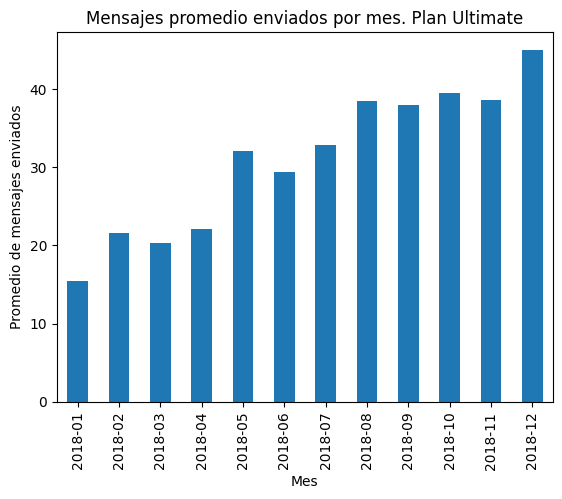

In [83]:
#Graficamos el promedio mensual obtenido para los mensajes enviados de los usuarios del plan Ultimate
promedio_mensajes_mes_ultimate.plot(title = "Mensajes promedio enviados por mes. Plan Ultimate",
                                        kind="bar", 
                                        x="date",
                                        y="message_qty",
                                        xlabel="Mes",
                                        ylabel="Promedio de mensajes enviados",
                                        legend=None)
plt.show()




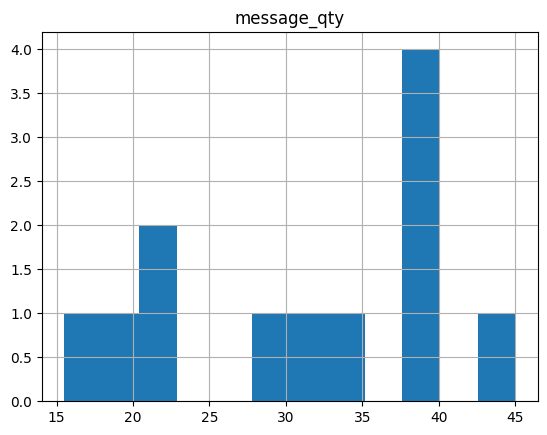

In [84]:
#Histograma del promedio de mensajes del plan ultimate
promedio_mensajes_mes_ultimate.hist(bins=12, alpha=1)
plt.show()


In [85]:
varianza_mensajes_mes_ultimate = analisis_plan_ultimate["message_qty"].var()
varianza_mensajes_mes_ultimate


1208.7567435481378

In [86]:
#Calculamos el promedio mensual de mensajes enviados de los usarios del plan Surf
promedio_mensajes_mes_surf = analisis_plan_surf.groupby("date")["message_qty"].mean().reset_index()
promedio_mensajes_mes_surf


,date,message_qty
0,2018-01,10.500000
1,2018-02,12.000000
2,2018-03,15.260870
3,2018-04,17.400000
4,2018-05,24.012987
5,2018-06,25.298969
6,2018-07,27.033058
7,2018-08,28.777778
8,2018-09,30.762887
9,2018-10,33.839662


In [87]:
promedio_mensajes_mes_surf["message_qty"].describe()

count    12.000000
mean     24.656000
std       9.049246
min      10.500000
25%      16.865217
50%      26.166013
75%      31.168455
max      38.600629
Name: message_qty, dtype: float64

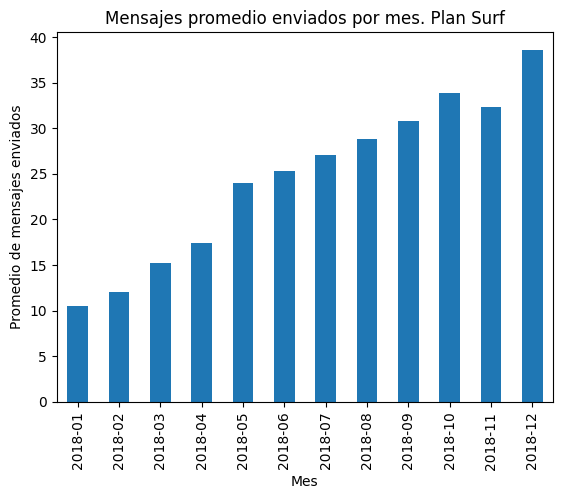

In [88]:
#Graficamos los promedios de cada mes de los mensajes enviados por los usuarios del Plan Surf
promedio_mensajes_mes_surf.plot(title = "Mensajes promedio enviados por mes. Plan Surf",
                                        kind="bar", 
                                        x="date",
                                        y="message_qty",
                                        xlabel="Mes",
                                        ylabel="Promedio de mensajes enviados",
                                        legend=None)
plt.show()



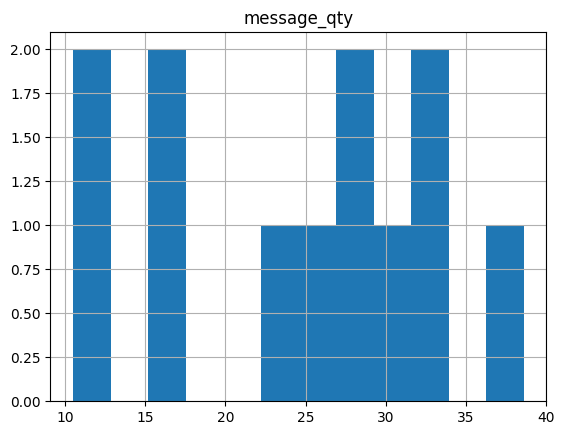

In [89]:
#Histograma del promedio de mensajes plan surf
promedio_mensajes_mes_surf.hist(bins=12, alpha=1)
plt.show()


In [90]:
#Varianza en los mensajes del plan Surf
varianza_mensajes_mes_surf = analisis_plan_surf["message_qty"].var()
varianza_mensajes_mes_surf




1126.7245219504066

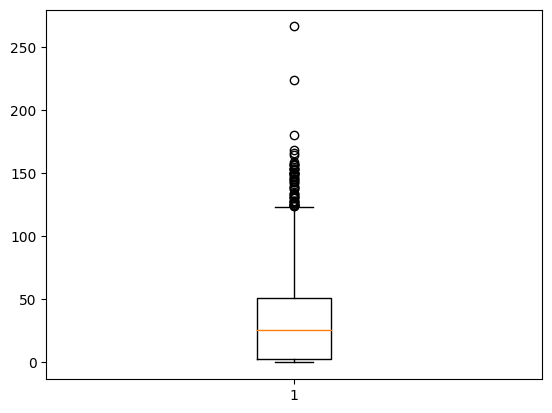

In [91]:
gasto_completo_usuario_mensual_boxplot= plt.boxplot(gasto_completo_usuario_mensual["message_qty"])
plt.show()


[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Buena manera de mostrar los datos de la misma manera que en `llamadas`, así se mantiene una constancia a lo largo del proyecto
</div>


En este caso existe una diferencia entre la cantidad de mensajes que envian los usuarios de cada plan, sin embargo, no se ve tan marcada como la diferncia entre las llamadas hechas por los usuarios.

### Internet

In [92]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
#Obtenemos la cantidad promedio de mb usados de manera mensual por los usuarios del plan surf
promedio_datos_usados_mes_surf = analisis_plan_surf.groupby("date")["mb_used"].mean().reset_index()
promedio_datos_usados_mes_surf




,date,mb_used
0,2018-01,4881.000000
1,2018-02,12192.888889
2,2018-03,13361.043478
3,2018-04,11998.200000
4,2018-05,13953.246753
5,2018-06,15319.567010
6,2018-07,16803.181818
7,2018-08,16814.864198
8,2018-09,16610.912371
9,2018-10,17331.721519


In [93]:
promedio_datos_usados_mes_surf.describe()

,mb_used
count,12.000000
mean,14481.579403
std,3647.076942
min,4881.000000
25%,13069.004831
50%,15839.053823
75%,16806.102413
max,18153.786164


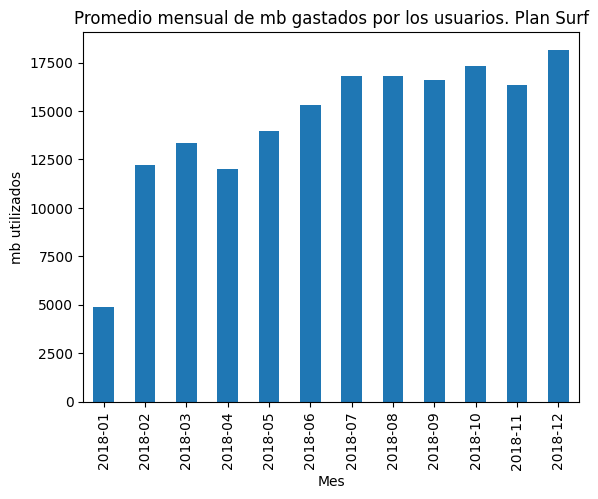

In [94]:
#Graficamos los promedios obtenidos para cada mes del uso de mb de los usuarios del plan surf
promedio_datos_usados_mes_surf.plot(title = "Promedio mensual de mb gastados por los usuarios. Plan Surf",
                                        kind="bar", 
                                        x="date",
                                        y="mb_used",
                                        xlabel="Mes",
                                        ylabel="mb utilizados",
                                        legend=None)
plt.show()


In [95]:
varianza_datos_usados_mes_surf = analisis_plan_surf["mb_used"].var()
varianza_datos_usados_mes_surf


64343620.21550206

In [96]:
#Obtenemos los promedios de manera mensual de los mb usados por los usuarios del plan Ultimate
promedio_datos_usados_mes_ultimate = analisis_plan_ultimate.groupby("date")["mb_used"].mean().reset_index()
promedio_datos_usados_mes_ultimate


,date,mb_used
0,2018-01,6926.250000
1,2018-02,17148.857143
2,2018-03,18340.250000
3,2018-04,16140.476190
4,2018-05,16643.758621
5,2018-06,15355.106383
6,2018-07,16363.677966
7,2018-08,17834.887324
8,2018-09,16989.395349
9,2018-10,17633.188679


In [97]:
promedio_datos_usados_mes_ultimate.describe()

,mb_used
count,12.000000
mean,16231.183077
std,3061.364046
min,6926.250000
25%,16307.877522
50%,17021.504761
75%,17683.613340
max,18344.735099


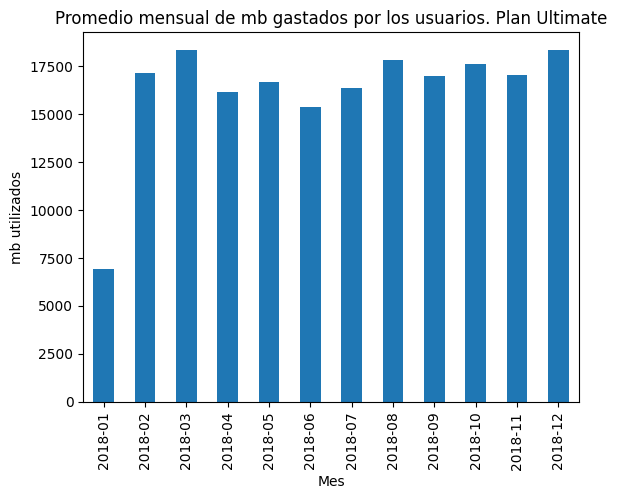

In [98]:
#Graficamos los promedios obtenidos de manera mensual de los mb gastados de los usuarios del plan Ultimate
promedio_datos_usados_mes_ultimate.plot(title = "Promedio mensual de mb gastados por los usuarios. Plan Ultimate",
                                        kind="bar", 
                                        x="date",
                                        y="mb_used",
                                        xlabel="Mes",
                                        ylabel="mb utilizados",
                                        legend=None)
plt.show()


In [99]:
varianza_datos_usados_mes_ultimate= analisis_plan_surf["message_qty"].var()
varianza_datos_usados_mes_ultimate


1126.7245219504066

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

Si, los usuarios en promedio usan mas mb al mes en el plan ultimate, esto puede deberse a que este plan incluye mas mb que el plan surf

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Gracias a estos analisis podemos crear nuevas estrategias para optimizar los planes y dar un mayor beneficio a cambio de mejores ingresos
</div>


## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

In [100]:
#Promedio de los ingresos del plan SURF (costo de 20 dls) 
analisis_plan_surf["costo_total"].mean()

56.303242212333124

In [101]:
#Calculamos el promedio del ingreso total para cada uno de los meses del plan surf
promedio_ingresos_totales_mensuales_surf = analisis_plan_surf.groupby("date")["costo_total"].mean().reset_index()
promedio_ingresos_totales_mensuales_surf

,date,costo_total
0,2018-01,20.000000
1,2018-02,32.444444
2,2018-03,43.347826
3,2018-04,38.220000
4,2018-05,44.402597
5,2018-06,45.113402
6,2018-07,57.917355
7,2018-08,59.820988
8,2018-09,54.324742
9,2018-10,60.717300


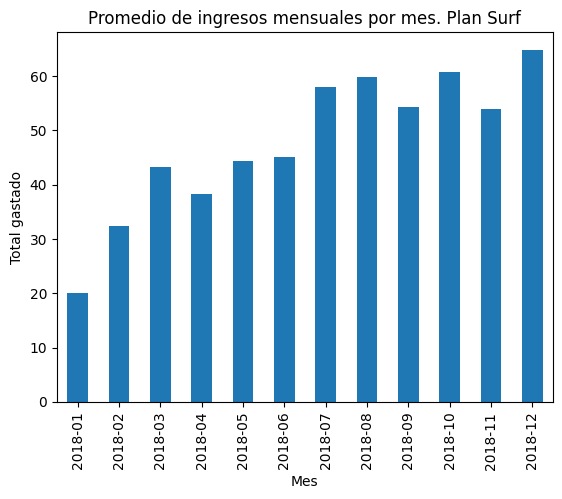

In [102]:
#Graficamos los promedios de ingreso total obtenidos para cada mes del plan surf
promedio_ingresos_totales_mensuales_surf.plot(title="Promedio de ingresos mensuales por mes. Plan Surf",
                                             kind="bar",
                                             x="date",
                                             y="costo_total",
                                             xlabel="Mes",
                                             ylabel="Total gastado",
                                             legend=None)
plt.show()

In [103]:
varianza_ingresos_totales_mensuales_surf = analisis_plan_surf["costo_total"].var()
varianza_ingresos_totales_mensuales_surf

2832.6058228147053

In [104]:
##Promedio de los ingresos del plan ULTIMATE (costo de 70 dls) 
analisis_plan_ultimate["costo_total"].mean()

72.15972222222223

In [105]:
#Calculamos el promedio de los ingresos totales de forma mensual correspondiente a los usuarios del plan ultimate
promedio_ingresos_totales_mensuales_ultimate = analisis_plan_ultimate.groupby("date")["costo_total"].mean().reset_index()
promedio_ingresos_totales_mensuales_ultimate

,date,costo_total
0,2018-01,70.000000
1,2018-02,70.000000
2,2018-03,73.500000
3,2018-04,72.857143
4,2018-05,70.551724
5,2018-06,71.510638
6,2018-07,71.864407
7,2018-08,72.718310
8,2018-09,71.860465
9,2018-10,72.132075


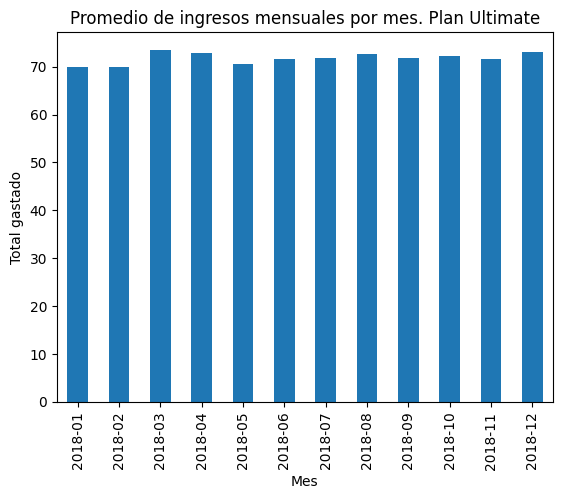

In [106]:
#Graficamos los promedios obtenidos de los ingresos correspondientes a los usuarios del plan ultimate
promedio_ingresos_totales_mensuales_ultimate.plot(title="Promedio de ingresos mensuales por mes. Plan Ultimate",
                                             kind="bar",
                                             x="date",
                                             y="costo_total",
                                             xlabel="Mes",
                                             ylabel="Total gastado",
                                             legend=None)
plt.show()

In [107]:
#Obtenemos la varianza
varianza_ingresos_totales_mensuales_ultimate = analisis_plan_ultimate["costo_total"].var()
varianza_ingresos_totales_mensuales_ultimate

119.16082328851802

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

La diferencia de los ingresos en relacion al costo base de cada uno de los planes es muy diferente, los cleintes del plan surf suelen exceder con mayor frecuencia los beneficios del plan, mientras que eso no es muy comun en el plan ultimate, y lo podemos ver muy claramente en los promedios y la varianza. 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Aquí recomendaría mostrar diagramas de caja que resalten las diferencias entre las distribuciones de cada uno de los planes, de esta manera podemos ver como hay una gran diferencia entre ambos
</div>


## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [108]:
# Prueba las hipótesis
# La hipotesis nula consiste en que los ingresos promedio de los usuarios de los planes de llamada Ultimate y Surf son iguales. 
#Como hipotesis laternativa, tenemos que los ingresos promedio de los usuarios de los planes de llamada Ultimate y Surf son distintos.

#Aplicaremos una prueba T-Student, para comparar las muestras de cada uno de los planes.
#Obtener muestras de los ingresos promedio mensuales de ambos planes

#Plan Surf

muestra_aleatoria_ingresos_mensuales_surf = []
obtener_muestra_aleatoria_ingresos_mensuales_surf = analisis_plan_surf.sample(30)



for row in obtener_muestra_aleatoria_ingresos_mensuales_surf["costo_total"]:
    muestra_aleatoria_ingresos_mensuales_surf.append(row)
print(muestra_aleatoria_ingresos_mensuales_surf)


    
#Plan Ultimate
muestra_aleatoria_ingresos_mensuales_ultimate = []
obtener_muestra_aleatoria_ingresos_mensuales_ultimate = analisis_plan_ultimate.sample(30)
for row in obtener_muestra_aleatoria_ingresos_mensuales_ultimate["costo_total"]:
    muestra_aleatoria_ingresos_mensuales_ultimate.append(row)
print(muestra_aleatoria_ingresos_mensuales_ultimate)



[20.0, 52.0, 23.0, 20.0, 45.0, 24.0, 74.0, 40.0, 37.0, 27.0, 21.0, 20.0, 20.0, 20.0, 62.0, 99.0, 45.0, 33.0, 54.0, 119.0, 114.0, 22.0, 20.0, 56.0, 20.0, 50.0, 20.0, 20.0, 93.0, 30.0]
[70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 112.0, 70.0, 70.0, 70.0, 80.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 70.0, 91.0, 70.0, 70.0, 70.0, 70.0]


In [109]:

alpha = 0.05 #Establecemos un nivel de significancia del 5%
results = st.ttest_ind(muestra_aleatoria_ingresos_mensuales_ultimate, muestra_aleatoria_ingresos_mensuales_surf, equal_var=False) #realizamos la prueba, anteriormente habiamos obtenido varianzas distintas en los planes Surf y Ultimate
print('valor p: ', results.pvalue)
if results.pvalue < alpha: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


valor p:  9.82483202119455e-06
Rechazamos la hipótesis nula


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [110]:
# Prueba las hipótesis
#Nuestra hipotesis nula será que el ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones
#Nuestra hipotesis alternativa será que el ingreso promedio de los usuarios del área NY-NJ es distinto al de los usuarios de otras regiones

#Obtener muestra de los usuarios del área NY-NJ
df_users["city"].unique()


array(['Atlanta-Sandy Springs-Roswell, GA MSA',
       'Seattle-Tacoma-Bellevue, WA MSA',
       'Las Vegas-Henderson-Paradise, NV MSA', 'Tulsa, OK MSA',
       'Dallas-Fort Worth-Arlington, TX MSA',
       'San Francisco-Oakland-Berkeley, CA MSA',
       'Grand Rapids-Kentwood, MI MSA',
       'Orlando-Kissimmee-Sanford, FL MSA',
       'San Jose-Sunnyvale-Santa Clara, CA MSA',
       'Cleveland-Elyria, OH MSA',
       'Chicago-Naperville-Elgin, IL-IN-WI MSA', 'Knoxville, TN MSA',
       'New York-Newark-Jersey City, NY-NJ-PA MSA', 'Pittsburgh, PA MSA',
       'Fresno, CA MSA',
       'Washington-Arlington-Alexandria, DC-VA-MD-WV MSA',
       'Indianapolis-Carmel-Anderson, IN MSA', 'Jacksonville, FL MSA',
       'Los Angeles-Long Beach-Anaheim, CA MSA',
       'Omaha-Council Bluffs, NE-IA MSA',
       'Houston-The Woodlands-Sugar Land, TX MSA',
       'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA',
       'Tampa-St. Petersburg-Clearwater, FL MSA',
       'Birmingham-Hoover, AL MSA'

In [111]:
#Muestra de usuarios del área NY-NJ
dt_usuarios_ny_nj = df_users.query("city == 'New York-Newark-Jersey City, NY-NJ-PA MSA'")
dt_usuarios_ny_nj["user_id"].nunique() #conteo de usuarios de la zona NY-NJ 



80

In [112]:
dt_usuarios_ny_nj

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
14,1014,Edmundo,Simon,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-25,surf,NaN
22,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07
24,1024,Yuki,Tyson,74,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-08-21,surf,NaN
27,1027,Georgeanna,Cardenas,38,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-26,surf,NaN
31,1031,Lane,Martin,52,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-07-15,ultimate,NaN
...,...,...,...,...,...,...,...,...
469,1469,Rory,Nixon,75,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-06-04,surf,NaN
482,1482,Armand,Glenn,70,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-01-01,ultimate,NaN
494,1494,Preston,Downs,70,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-19,surf,NaN
495,1495,Fidel,Sharpe,67,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-09-04,surf,NaN


In [113]:
#Cotamos la cantidad de usuarios obtenidos
muestra_usuarios_ny_nj = dt_usuarios_ny_nj.merge(gasto_completo_usuario_mensual, on="user_id")
muestra_usuarios_ny_nj["user_id"].nunique()




79

In [114]:
muestra_usuarios_ny_nj

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,date,min_qty,...,mb_used,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,costo_total
0,1014,Edmundo,Simon,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-25,surf,NaN,2018-11,28.0,...,1176.0,surf,50,15360,500,20,10,0.03,0.03,20.0
1,1014,Edmundo,Simon,61,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-11-25,surf,NaN,2018-12,150.0,...,7803.0,surf,50,15360,500,20,10,0.03,0.03,21.0
2,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07,2018-05,39.0,...,4915.0,surf,50,15360,500,20,10,0.03,0.03,20.0
3,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07,2018-06,76.0,...,23470.0,surf,50,15360,500,20,10,0.03,0.03,100.0
4,1022,Bo,Snow,73,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-04-20,surf,2018-09-07,2018-07,70.0,...,9946.0,surf,50,15360,500,20,10,0.03,0.03,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN,2018-08,44.0,...,20290.0,surf,50,15360,500,20,10,0.03,0.03,69.0
373,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN,2018-09,45.0,...,22853.0,surf,50,15360,500,20,10,0.03,0.03,94.0
374,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN,2018-10,46.0,...,20604.0,surf,50,15360,500,20,10,0.03,0.03,72.0
375,1498,Scot,Williamson,51,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-02-04,surf,NaN,2018-11,41.0,...,19192.0,surf,50,15360,500,20,10,0.03,0.03,58.0


In [115]:
#Crear DF de usuarios sin clientes de NY-NJ
dt_usuarios_general = df_users.query("city != 'New York-Newark-Jersey City, NY-NJ-PA MSA'")
dt_usuarios_general["user_id"].nunique() #conteo de usuarios del resto de zonas



420

In [116]:
dt_usuarios_general

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN
...,...,...,...,...,...,...,...,...
492,1492,Elvie,Jones,63,"Portland-Vancouver-Hillsboro, OR-WA MSA",2018-03-07,surf,NaN
493,1493,Cicely,Wynn,18,"Boston-Cambridge-Newton, MA-NH MSA",2018-03-06,ultimate,NaN
496,1496,Ariel,Shepherd,49,"New Orleans-Metairie, LA MSA",2018-02-20,surf,NaN
497,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN


In [117]:
#Obtenemos una tabla con la informacion completa del filtrado obtenido anteriormente
dt_usuarios_general = dt_usuarios_general.merge(gasto_completo_usuario_mensual, on="user_id")


In [118]:
dt_usuarios_general

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,date,min_qty,...,mb_used,plan_name,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,costo_total
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,2018-12,16.0,...,1903.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,2018-08,27.0,...,6929.0,surf,50,15360,500,20,10,0.03,0.03,20.0
2,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,2018-09,49.0,...,13333.0,surf,50,15360,500,20,10,0.03,0.03,20.0
3,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,2018-10,65.0,...,22356.0,surf,50,15360,500,20,10,0.03,0.03,89.0
4,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,2018-11,64.0,...,18524.0,surf,50,15360,500,20,10,0.03,0.03,51.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1911,1497,Donte,Barrera,49,"Los Angeles-Long Beach-Anaheim, CA MSA",2018-12-10,ultimate,NaN,2018-12,54.0,...,11120.0,ultimate,1000,30720,3000,70,7,0.01,0.01,70.0
1912,1499,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN,2018-09,41.0,...,13004.0,surf,50,15360,500,20,10,0.03,0.03,20.0
1913,1499,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN,2018-10,53.0,...,19515.0,surf,50,15360,500,20,10,0.03,0.03,61.0
1914,1499,Shena,Dickson,37,"Orlando-Kissimmee-Sanford, FL MSA",2018-05-06,surf,NaN,2018-11,45.0,...,16834.0,surf,50,15360,500,20,10,0.03,0.03,35.0


In [119]:
#Obtener la varianza y promedio para cada DF
ingresos_promedio_ny_nj=muestra_usuarios_ny_nj["costo_total"].mean()
varianza_ingresos_ny_nj=muestra_usuarios_ny_nj["costo_total"].var()
print(f"Ingresos promedio de la region NY-NJ:{ingresos_promedio_ny_nj}, varianza:{varianza_ingresos_ny_nj}")

ingresos_promedio_general=dt_usuarios_general["costo_total"].mean()
varianza_ingresos_general=dt_usuarios_general["costo_total"].var()
print(f"Ingresos promedio de los usuarios en general:{ingresos_promedio_general}, varianza: {varianza_ingresos_general}")

Ingresos promedio de la region NY-NJ:56.54907161803713, varianza:1769.9503781251763
Ingresos promedio de los usuarios en general:62.213465553235906, varianza: 2082.041614928839


In [121]:
#Obtencion de muestras aleatoreas de la region de NY-NJ y el resto de las regiones
muestra_aleatoria_ingresos_mensuales_ny_nj = []
obtener_muestra_aleatoria_ingresos_mensuales_ny_nj = muestra_usuarios_ny_nj.sample(30)



for row in obtener_muestra_aleatoria_ingresos_mensuales_ny_nj["costo_total"]:
    muestra_aleatoria_ingresos_mensuales_ny_nj.append(row)
print(muestra_aleatoria_ingresos_mensuales_ny_nj)


muestra_aleatoria_ingresos_mensuales_general = []
obtener_muestra_aleatoria_ingresos_mensuales_general = dt_usuarios_general.sample(30)



for row in obtener_muestra_aleatoria_ingresos_mensuales_general["costo_total"]:
    muestra_aleatoria_ingresos_mensuales_general.append(row)
print(muestra_aleatoria_ingresos_mensuales_general)



[29.0, 25.0, 20.0, 85.0, 124.0, 70.0, 20.0, 20.0, 82.0, 20.0, 20.0, 114.0, 70.0, 44.0, 20.0, 129.0, 72.0, 124.0, 99.0, 20.0, 20.0, 78.0, 59.0, 70.0, 56.0, 66.0, 20.0, 41.0, 112.0, 20.0]
[20.0, 20.0, 21.0, 20.0, 70.0, 82.0, 70.0, 106.0, 77.0, 21.0, 20.0, 20.0, 73.0, 32.0, 20.0, 68.0, 70.0, 70.0, 70.0, 23.0, 70.0, 70.0, 70.0, 51.0, 70.0, 70.0, 70.0, 20.0, 70.0, 70.0]


In [122]:
#Como hipotesis nula tenemos que el proemdio de los ingresos de la region NY-NJ es igual al del resto de las regiones
#Como hipotesis alternativa, tenemos que el proemdio de los ingresos de la region NY-NJ es difente al del resto de las regiones
alpha_region = 0.05 #Establecemos un nivel de significancia del 5%
results_region = st.ttest_ind(muestra_aleatoria_ingresos_mensuales_ny_nj, muestra_aleatoria_ingresos_mensuales_general, equal_var=False) #realizamos la prueba, sabiendo que las varianzas son distintas
print('valor p: ', results_region.pvalue)
if results_region.pvalue < alpha_region: # comparar el valor p con el umbral
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


valor p:  0.5642459541279161
No podemos rechazar la hipótesis nula


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

La aplicación de las pruebas de hipotesis me parece acertada, seleccionando los datos y valores correctos
</div>


## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]

Nos damos cuenta de que algunos de los usuarios no cuentan con registro de llamadas, mensajes o mb gastados durante el periodo mensual de su plan, lo que nos puede dar una idea del comportamiento que estos usuarios tienen, y de las preferencias de servicios que usa cada uno de ellos.

En el caso del plan Surf, oibtuvimos un promedio de 56.30 dls de costo total por usuario, siendo que el costo base del plan es de 20 dls, tenemos una diferencia de casi el 200% del costo del plan, esto se debe a que la cantidad de servicios que ofrece dicho plan es algo limitada, y los usuarios suelen exceder las capacidades del plan, por lo que se hacen cargos extras por usar una cantidad de servicios fuera del plan. Mientras que para los ingresos proemdio del plan Ultimate obtuvimos 72.15 dls, siendo que este plan tiene un costo base de 70 dls, vemos que los usuarios no suelen exceder los servicios del plan al ser este mas amplio, por lo que no es muy normal que se generen cargos recurrentes en este caso.

La cantidad de usuarios del plan surf, es significativamente mayor que la cantidad de usuarios del plan ultimate, y seguramente se debe al costo mas bajo del plan surf.



Al realizar la prueba T-Student podemos ver que los ingresos del plan surf y ultimate son distintos
Y al comparar la regio de NY-NJ contra el resto de las regiones en general, tenemos que no tenemos una diferencia significativa en los promedios que nos haga afirmar que los ingresos son distintos en esta comparacion. 

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un muy buen trabajo al desarrollar este proyecto, las observaciones que has hecho a lo largo del mismo han servido para tomar acción en los pasos posteriores, terminando en resultados positivos.

Este es un proyecto que nos adentra mucho en los analisis que se hacen recurrentemente en las compañías donde se obtiene información para tomar decisiones sobre el negocio que impactan directamente los ingresos, lo has hecho bastante bien!

Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!    
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
- Las graficas utilizadas me parecen del tipo correcto
- El proyecto esta ordenado
    
</div>

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Mejorar la limpieza del código, debemos imprimir solo los datos cuando estos aportan información valiosa al analisis de los mismos, si son impresiones que usamos para pruebas de nuestro código, debemos eliminarlas después de utilizarlas

</div>
